In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

  Activating project at `~/projects/EccentricBurstTimings`


In [54]:
using Syzygy, CairoMakie, StaticArrays
using LinearAlgebra: norm, dot, ×
using Peaks

In [60]:
function PN_eccentricity(r1, r2, v1, v2, m1, m2, G, c)
    E = total_energy_PN2(r1, r2, v1, v2, m1, m2, G, c) + total_energy_PN2(r2, r1, v2, v1, m2, m1, G, c)
    M = m1 + m2
    ν = (m1 * m2)/M^2
    μ = M*ν# reduced mass
    ε = -2*E/(μ*c^2)

    J = norm(μ .* (r1 - r2) × (v1 - v2))
    h = J/(G*M)
    j = -2E*h^2/μ^3

    e² = 1 - j + ε/4*(24 - 4ν + 5j*(-3 + ν)) + 
                 ε^2/8*(52 + 2ν + 2ν^2 - j*(80 - 55ν + 4ν^2) - 8/j*(-17 + 11ν)) + 
                 ε^3/192*(-768 - 6ν*π^2 - 344ν - 216*ν^2 + 3j*(-1488 - 1556ν - 319*ν^2 + 4ν^3) -
                          4/j*(588 - 8212ν + 177ν*π^2 + 480ν^2) +
                          192/j^2*(134 - 281ν + 5ν*π^2 + 16ν^2))

    √e²
end

function PN_semi_major_axis(r1, r2, v1, v2, m1, m2, G, c)
    E = total_energy_PN2(r1, r2, v1, v2, m1, m2, G, c) + total_energy_PN2(r2, r1, v2, v1, m2, m1, G, c)
    M = m1 + m2
    ν = (m1 * m2)/M^2
    μ = M*ν# reduced mass
    ε = -2*E/(μ*c^2)

    J = norm(μ .* (r1 - r2) × (v1 - v2))
    h = J/(G*M)
    j = -2E*h^2/μ^3

    G*M/(ε*c^2)*( 1 + ε/4*(-7 + ν) + 
                       ε^2/16*(1 + 10ν + ν^2 + 1/j*(068 + 44ν)) +
                       ε^3/192*(3 - 9ν - 6ν^2 + 3ν^3 + 1/j*(864 + (-3π^2 - 2212)*ν + 432ν^2) +
                                1/j^2*(-6432 + (13488 - 240π^2)*ν - 768ν^2))) 
end

function total_energy_PN2(r1, r2, v1, v2, m1, m2, G, c)
    c² = c^2
    c⁴ = c^4

    r = r1 - r2
    r12 = norm(r1 - r2)
    n12 = r ./ r12

    vv1 = norm(v1)
    vv2 = norm(v2)

    n12v1 = dot(n12, v1)
    n12v2 = dot(n12, v2)

    v1v2 = dot(v1, v2)

    E_Newt = 0.5*m1*vv1^2 - G*m1*m2/2r12
    E_1PN = 1/c²*(G^2*m1^2*m2/2r12^2 + 3m1*vv1^4/8 + G*m1*m2/r12*(-0.25*n12v1*n12v2 + 1.5*vv1^2 - 7/4*v1v2))
    E_2PN = 1/c⁴*(-G^3*m1^3*m2/2r12^3 - 19*G^3*m1^2*m2^2/8r12^3 + 5m1*vv1^6/16 + 
                  G*m1*m2/r12*(3/8*n12v1^3*n12v2 + 3/16*n12v1^2*n12v2^2 - 9/8*n12v1*n12v2*vv1^2 -
                               13/8*n12v2^2*vv1^2 + 21/8*vv1^4 + 13/8*n12v1^2*v1v2 + 3/4*n12v1*n12v2*v1v2 -
                               -55/8*vv1^2*v1v2 + 17/8*v1v2^2 + 31/16*vv1^2*vv2^2) +
                  G^2*m1^2*m2/r12^2*(29/4*n12v1^2 - 13/4*n12v1*n12v2 + 0.5*(n12v2^2 - 3/2*vv1^2 + 7/4*vv2^2))
                  )
    E = E_Newt + E_1PN + E_2PN
    # E_2p5PN = E + 4*G^2*m1^2*m2/(5*c^5*r12^2)*n12v1*(norm(v1 - v2)^2 - 2*G*(m1 - m2)/r12)
    return E #- E_2p5PN
end

function PN_eccentricity(sol::Syzygy.MultiBodySolution, indices=eachindex(sol.t))
    G, c = Syzygy.GRAVCONST, Syzygy.LIGHTSPEED
    e = zeros(length(indices))

    m1, m2 = sol.ic.particles.mass[[1, 2]]

    M12⁻¹ = 1/(m1 + m2)
    for (iter, i) in enumerate(indices)
        r1 = SVector{3}(sol.r[:,1,i])
        r2 = SVector{3}(sol.r[:,2,i])

        v1 = SVector{3}(sol.v[:,1,i])
        v2 = SVector{3}(sol.v[:,2,i])

        r_com = @. M12⁻¹*(m1*r1 + m2*r2)
        v_com = @. M12⁻¹*(m1*v1 + m2*v2)

        r1 = r1 - r_com
        v1 = v1 - v_com

        r2 = r2 - r_com
        v2 = v2 - v_com

        e[iter] = PN_eccentricity(r1, r2, v1, v2, m1, m2, G, c)
    end

    return e

end

function PN_semi_major_axis(sol::Syzygy.MultiBodySolution, indices=eachindex(sol.t))
    G, c = Syzygy.GRAVCONST, Syzygy.LIGHTSPEED
    a = zeros(length(indices))

    m1, m2 = sol.ic.particles.mass[[1, 2]]

    M12⁻¹ = 1/(m1 + m2)
    for (iter, i) in enumerate(indices)
        r1 = SVector{3}(sol.r[:,1,i])
        r2 = SVector{3}(sol.r[:,2,i])

        v1 = SVector{3}(sol.v[:,1,i])
        v2 = SVector{3}(sol.v[:,2,i])

        r_com = M12⁻¹ .* (m1 .* r1 + m2 .* r2)
        v_com = M12⁻¹ .* (m1 .* v1 + m2 .* v2)

        r1 = r1 - r_com
        v1 = v1 - v_com

        r2 = r2 - r_com
        v2 = v2 - v_com

        a[iter] = ustrip(Rsun, PN_semi_major_axis(r1, r2, v1, v2, m1, m2, G, c))
    end

    return a

end

function get_inner_orbital_elements(sol, indices=eachindex(sol.t)) 
    a = PN_semi_major_axis(sol, indices)
    e = PN_eccentricity(sol, indices)
    return a, e
end

get_inner_orbital_elements (generic function with 2 methods)

# Does the phase of the outer actually matter?

In [ ]:
masses = [35.0, 25.0, 6.0e8]Msun
e = [0.99, 0.0]
a = [1.8e-5/(1 - e[1]^2), 6.55]au
radii = Syzygy.gravitational_radius.(masses[1:2])
radii = [radii..., zero(radii[1])]

# triple = multibodysystem(masses, a=a, e=e, radii=radii, stellar_types=[14, 14, 14], true_anomaly=[1π, 0.7853981633974483])
# triple_V3 = multibodysystem(masses, a=a, e=e, radii=radii, stellar_types=[14, 14, 14], true_anomaly=[1π, π/2])

# pot = [PureGravitationalPotential(triple), PN2p5Potential(triple)]
# pot_V3 = [PureGravitationalPotential(triple_V3), PN2p5Potential(triple_V3)]

3-element Vector{Quantity{Float64, Dimensions{FRInt32}}}:
 51683.591554767496 m
  36916.85111054821 m
                0.0 m

In [132]:
masses = [35.0, 25.0]Msun
e = 0.99
a = 1.8e-5au/(1 - e[1]^2)

radii = Syzygy.gravitational_radius.(masses)
binary = multibodysystem(masses, a=a, e=e, radii=radii, stellar_types=[14, 14])
pot_bin = [PureGravitationalPotential(binary), PN2p5Potential(binary)]

2-element Vector{Syzygy.MultiBodyPotential}:
 PureGravitationalPotential{Float64}(1.0000000000000002, 0.0)
 PN2p5Potential{Float64}(1.0000000000000002, 1.0000000000000004, 1.0000000000000007, 1.8302431721760381e-9)

In [148]:
T = 180u"s"#1binary.binaries[1].P

sol = simulate(triple, t_sim=T, potential=pot, alg=Syzygy.ODESolvers.FineRKN5, force_dtmin=true, 
               callbacks=[], max_cpu_time=5, 
               abstol=1e-13, reltol=1e-13) |> postprocess;

sol_bin = simulate(binary, t_sim=T, potential=pot_bin, alg=Syzygy.ODESolvers.FineRKN5, force_dtmin=true, 
               callbacks=[], max_cpu_time=5, 
               abstol=1e-12, reltol=1e-12) |> postprocess;
               
println(sol.ode_system[:retcodes])
println(sol_bin.ode_system[:retcodes])
println(sol_bin.t[end]/binary.binaries[1].elements.P)

Dict{Symbol, Any}(:DiffEq => :Success)
Dict{Symbol, Any}(:DiffEq => :Success)
1.624104704713908 


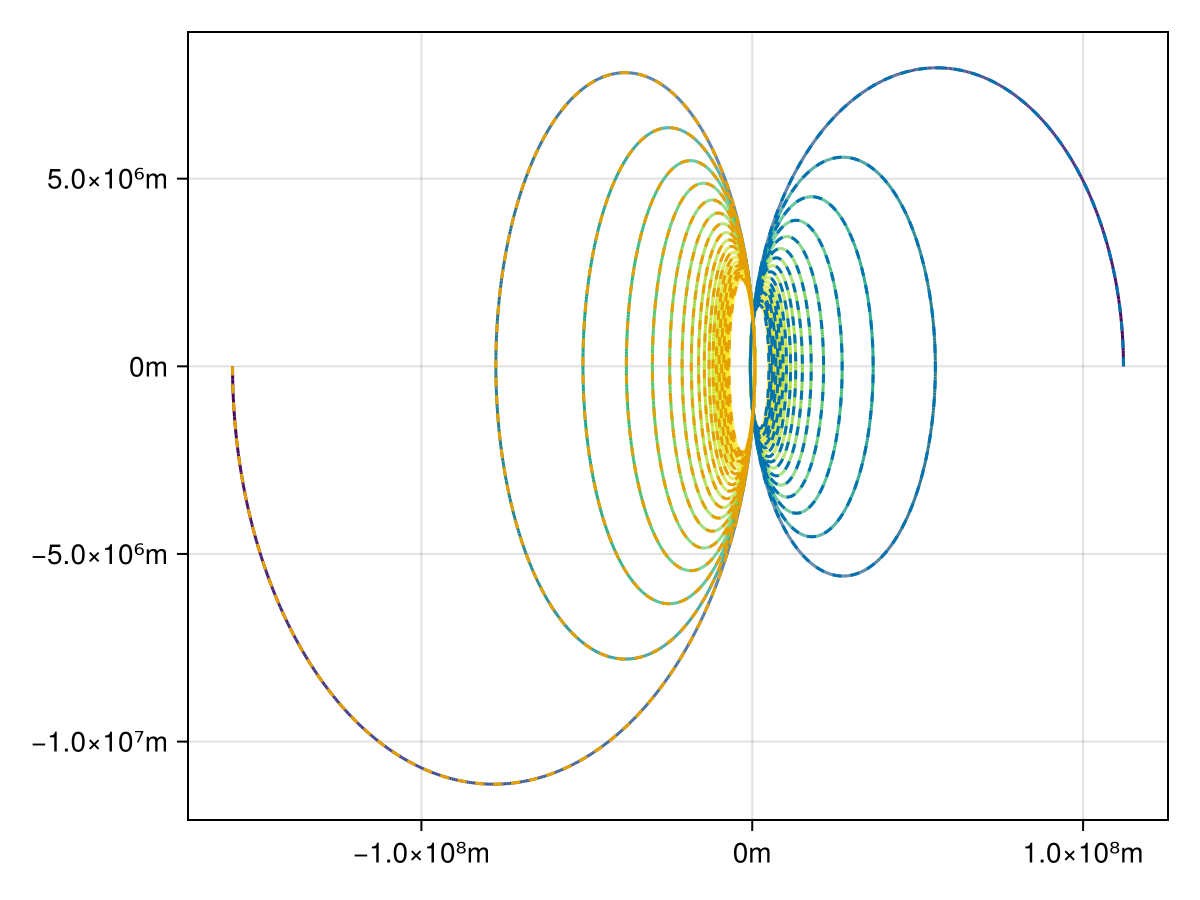

In [37]:
let fig = Figure()

    T = 180u"s"

    triple = multibodysystem(masses, a=a, e=e, radii=radii, stellar_types=[14, 14, 14], true_anomaly=[1π, 0.7853981633974483])
    pot = [PureGravitationalPotential(triple), PN2p5Potential(triple)]
    sol = simulate(triple, t_sim=T, potential=pot, alg=Syzygy.ODESolvers.FineRKN5, force_dtmin=true, 
               callbacks=[], max_cpu_time=5, 
               abstol=1e-13, reltol=1e-13) |> postprocess;

    sol_bin = let
        bin = multibodysystem(masses[1:2], a=a[1], e=e[1], radii=radii[1:2], stellar_types=[14, 14])
        pot = [PureGravitationalPotential(bin), PN2p5Potential(bin)]
        sol = simulate(bin, t_sim=T, potential=pot, alg=Syzygy.ODESolvers.FineRKN5, force_dtmin=true, 
                callbacks=[], max_cpu_time=5, 
                abstol=1e-13, reltol=1e-13) |> postprocess;
    end

    ax = Axis(fig[1, 1])
    let
        com = Syzygy.center_of_mass(sol, [1, 2])
        for i = 1:2
            r = sol.r[particle=i] .- com
            lines!(ax, r[1,:], r[2,:], color=ustrip.(u"s", sol.t))
        end
    end
    

    let
        com = Syzygy.center_of_mass(sol_bin, [1, 2])
        for i = 1:2
            r = sol_bin.r[particle=i] .- com
            lines!(ax, r[1,:], r[2,:], linestyle=:dash)
        end
    end
    fig
end

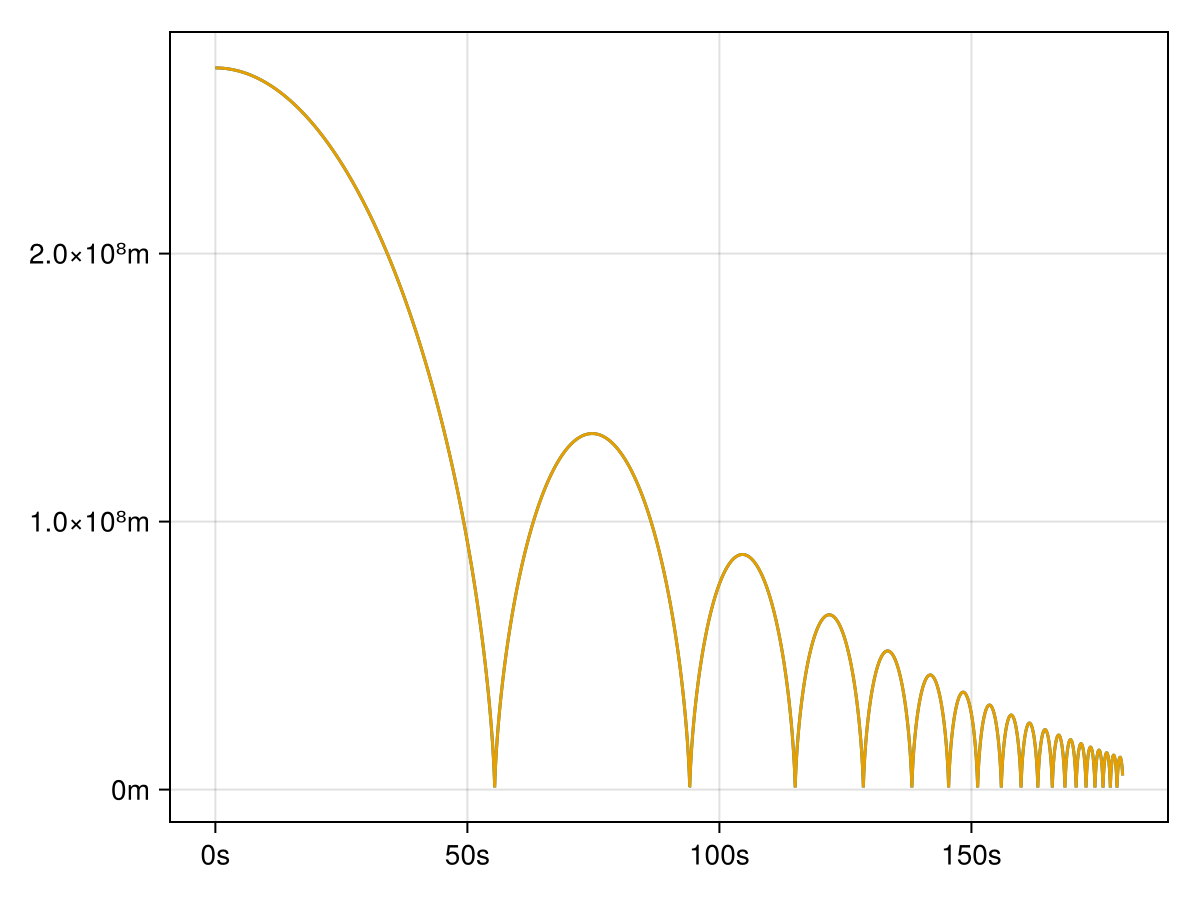

In [38]:
let fig = Figure()
    ax = Axis(fig[1, 1])

    T = 180u"s"

    triple = multibodysystem(masses, a=a, e=e, radii=radii, stellar_types=[14, 14, 14], true_anomaly=[1π, 0.7853981633974483])
    pot = [PureGravitationalPotential(triple), PN2p5Potential(triple)]
    sol = simulate(triple, t_sim=T, potential=pot, alg=Syzygy.ODESolvers.FineRKN5, force_dtmin=true, 
               callbacks=[], max_cpu_time=5, 
               abstol=1e-13, reltol=1e-13) |> postprocess;

    sol_bin = let
        bin = multibodysystem(masses[1:2], a=a[1], e=e[1], radii=radii[1:2], stellar_types=[14, 14])
        pot = [PureGravitationalPotential(bin), PN2p5Potential(bin)]
        sol = simulate(bin, t_sim=T, potential=pot, alg=Syzygy.ODESolvers.FineRKN5, force_dtmin=true, 
                callbacks=[], max_cpu_time=5, 
                abstol=1e-13, reltol=1e-13) |> postprocess;
    end

    d = norm.(eachcol(sol.r[particle=1] .- sol.r[particle=2]))
    db = norm.(eachcol(sol_bin.r[particle=1] .- sol_bin.r[particle=2]))

    n_min = min(length(d), length(db))
    lines!(ax, sol.t[1:n_min], d[1:n_min])
    lines!(ax, sol_bin.t[1:n_min], db[1:n_min])
    # let
    #     lines!(ax, sol.t, norm.(eachcol(sol.r[particle=1] .- sol.r[particle=2])))
    # end
    
    # let
    #     lines!(ax, sol_bin.t, norm.(eachcol(sol_bin.r[particle=1] .- sol_bin.r[particle=2])), linestyle=:dash)
    # end
    fig
end

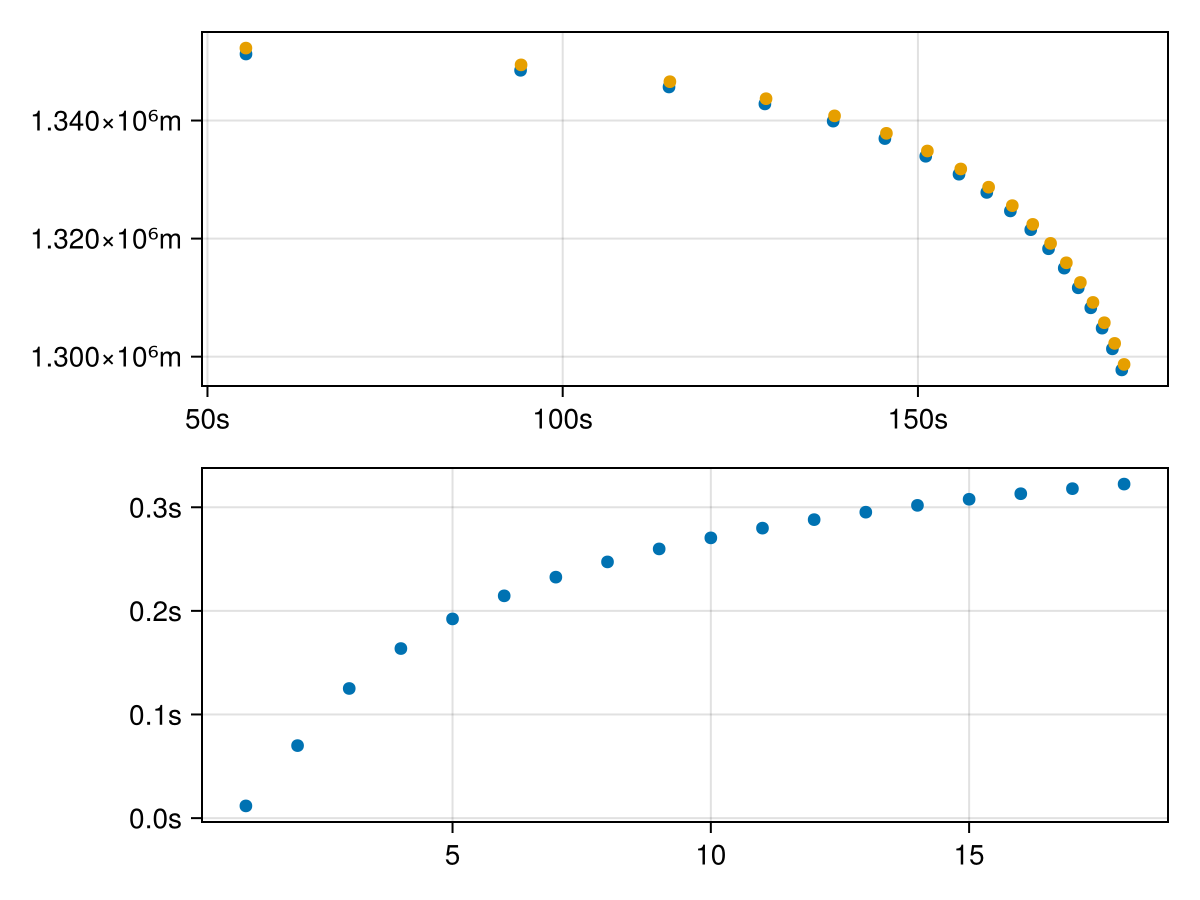

In [164]:
let
    T = 180u"s"#1binary.binaries[1].P

    sol = simulate(triple, t_sim=T, potential=pot, alg=Syzygy.ODESolvers.FineRKN5, force_dtmin=true, 
                callbacks=[], max_cpu_time=5, 
                abstol=1e-13, reltol=1e-13) |> postprocess;

    sol_V3 = simulate(triple_V3, t_sim=T, potential=pot, alg=Syzygy.ODESolvers.FineRKN5, force_dtmin=true, 
                callbacks=[], max_cpu_time=5, 
                abstol=1e-13, reltol=1e-13) |> postprocess;


    d = norm.(eachcol(sol.r[particle=1] .- sol.r[particle=2]))
    dV3 = norm.(eachcol(sol_V3.r[particle=1] .- sol_V3.r[particle=2]))

    # d = d ./ d[]#ustrip.(Rsun, d)
    # dV3 = dV3 ./ dV3[]#ustrip.(Rsun, dV3)

    ids, _ = findmaxima(-d)
    idsV3, _ = findmaxima(-dV3)
    n = min(length(ids), length(idsV3))
    
    fig = Figure()
    ax = Axis(fig[1, 1])
    ax2 = Axis(fig[2,1])
    scatter!(ax, sol.t[ids[1:n]], d[ids[1:n]])
    scatter!(ax, sol_V3.t[idsV3[1:n]], dV3[idsV3[1:n]])

    scatter!(ax2, abs.(sol.t[ids[1:n]] .- sol_V3.t[idsV3[1:n]]))
    fig
end

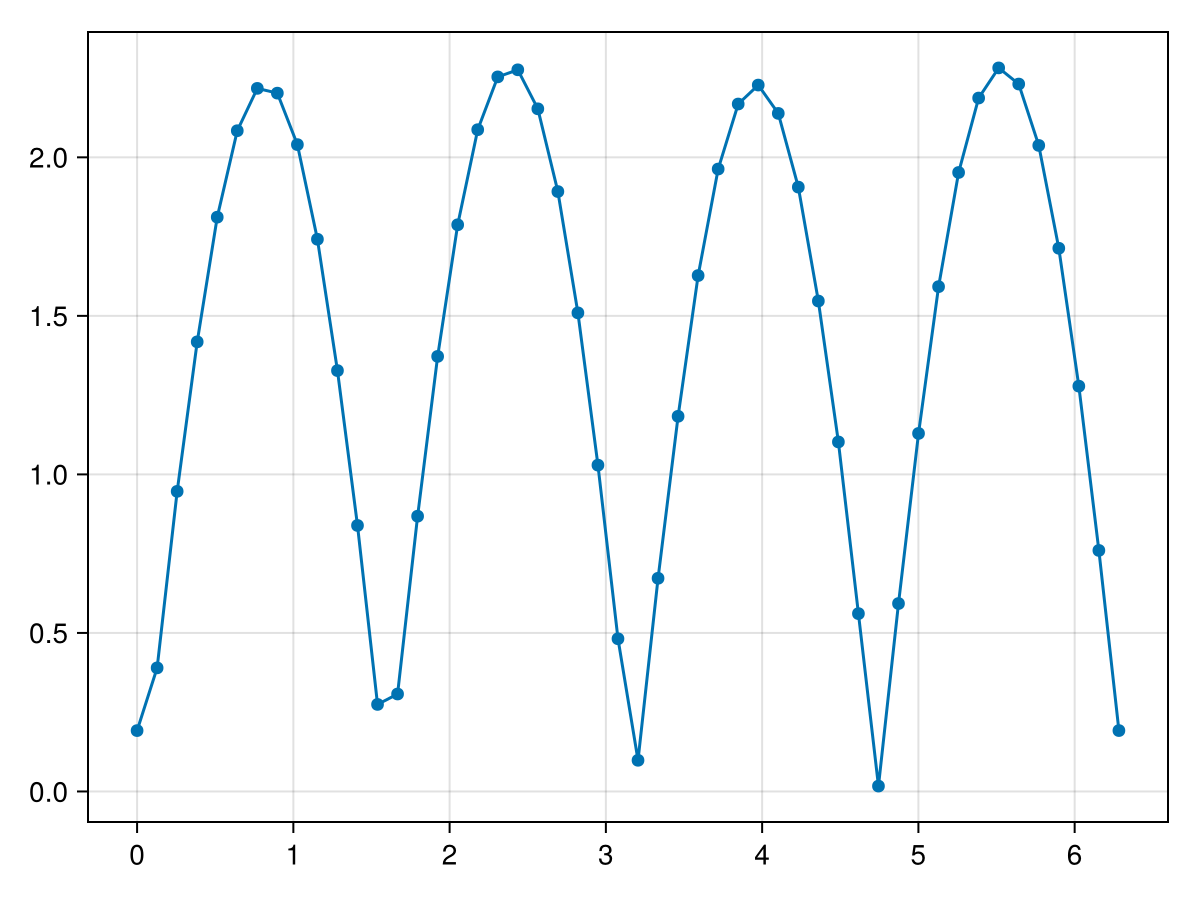

In [48]:
let
    T = 180u"s"
    νs = range(0, 2π, length=50)

    t_periapses_bin = let
        bin = multibodysystem(masses[1:2], a=a[1], e=e[1], radii=radii[1:2], stellar_types=[14, 14])
        pot = [PureGravitationalPotential(bin), PN2p5Potential(bin)]
        sol = simulate(bin, t_sim=T, potential=pot, alg=Syzygy.ODESolvers.FineRKN5, force_dtmin=true, 
                callbacks=[], max_cpu_time=5, 
                abstol=1e-13, reltol=1e-13) |> postprocess;
        d = norm.(eachcol(sol.r[particle=1] .- sol.r[particle=2]))
        ids, _ = findmaxima(-d)
        sol.t[ids]
    end

    dt_max = zeros(length(νs))
    Threads.@threads for i  = 1:length(νs)
        ν = νs[i]
        triple = multibodysystem(masses, a=a, e=e, radii=radii, stellar_types=[14, 14, 14], true_anomaly=[1π, ν])
        pot = [PureGravitationalPotential(triple), PN2p5Potential(triple)]
        sol = simulate(triple, t_sim=T, potential=pot, alg=Syzygy.ODESolvers.FineRKN5, force_dtmin=true, 
                callbacks=[], max_cpu_time=5, 
                abstol=1e-13, reltol=1e-13) |> postprocess;
        d = norm.(eachcol(sol.r[particle=1] .- sol.r[particle=2]))
        ids, _ = findmaxima(-d)

        ids = ids[findfirst(x -> x > 1u"s", sol.t[ids]):end]
        
        N = min(length(t_periapses_bin), length(ids))
        dt = abs.(t_periapses_bin[1:N] .- sol.t[ids[1:N]])
        dt_max[i] = ustrip(u"s", maximum(abs.(t_periapses_bin[1:N] .- sol.t[ids[1:N]])))
    end

    fig = Figure()
    ax = Axis(fig[1, 1])
    scatterlines!(ax, νs, dt_max)
    fig
end

Quantity{Float64, Dimensions{FRInt32}}[55.415141635917635 s, 94.1125465871149 s, 115.03686748598234 s, 128.5562737135417 s, 138.18408910532685 s, 145.4749764192663 s, 151.23505694043467 s, 155.92873120408655 s, 159.8447243695161 s, 163.1732725490166 s, 166.04528630641008 s, 168.55425358210212 s, 170.7688714125087 s, 172.74102315490376 s, 174.51060211854016 s, 176.10889702813213 s, 177.56084047106924 s, 178.8865789352472 s]
Quantity{Float64, Dimensions{FRInt32}}[7.457719951955857e-12 s, 7.457719951955856e-9 s, 55.41567717359727 s, 93.65984120983187 s, 114.23242712665764 s, 127.48721608301294 s, 136.90989373005922 s, 144.03678646468128 s, 149.66203039487684 s, 154.24267669956927 s, 158.06227778824453 s, 161.30753448067208 s, 164.10629489957398 s, 166.5505809651616 s, 168.70735015314014 s, 170.6274962409642 s, 172.34998985210802 s, 173.90531694687158 s, 175.31789398018276 s, 176.60733004529837 s, 177.78996207183556 s, 178.87865074302437 s, 179.884711498784 s]


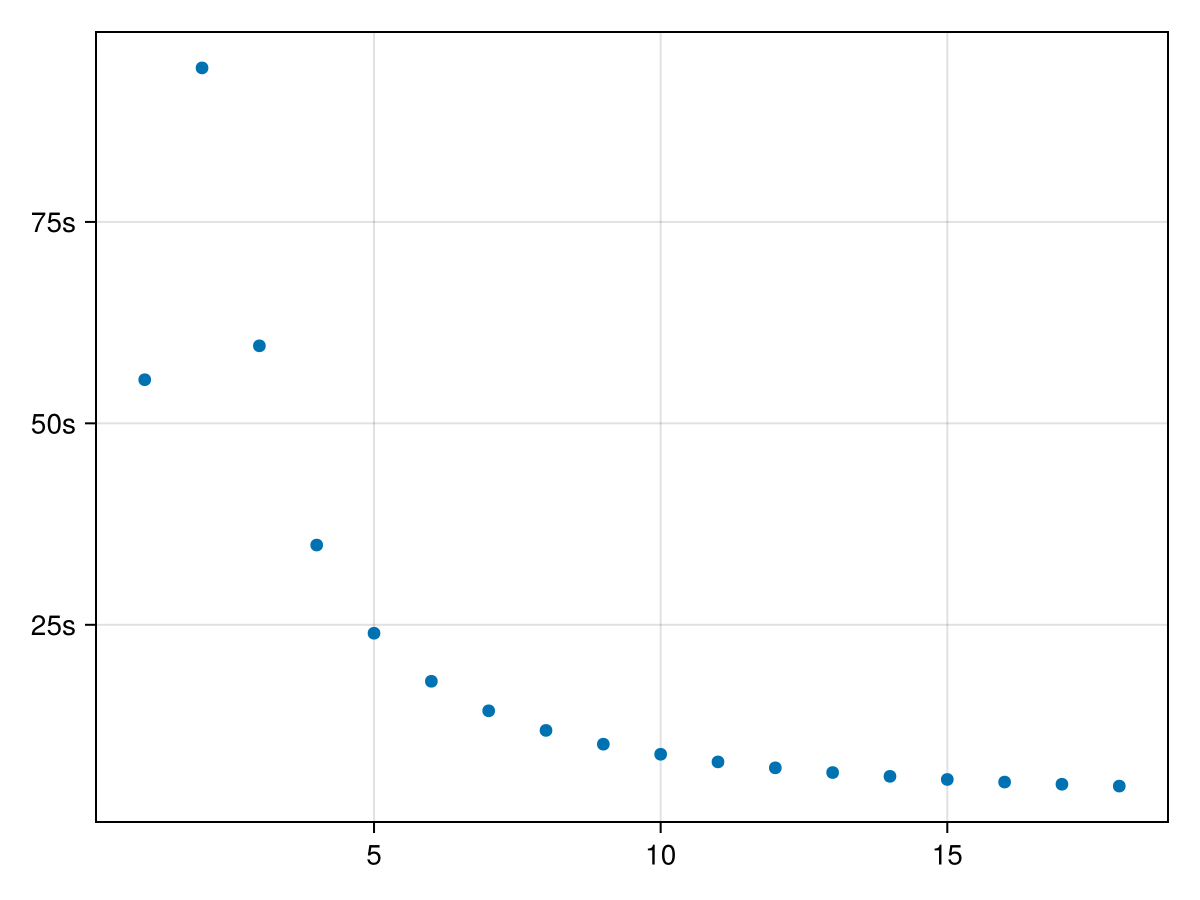

In [41]:
let
    T = 180u"s"
    νs = range(0, 2π, length=50)

    t_periapses_bin = let
        bin = multibodysystem(masses[1:2], a=a[1], e=e[1], radii=radii[1:2], stellar_types=[14, 14])
        pot = [PureGravitationalPotential(bin), PN2p5Potential(bin)]
        sol = simulate(bin, t_sim=T, potential=pot, alg=Syzygy.ODESolvers.FineRKN5, force_dtmin=true, 
                callbacks=[], max_cpu_time=5, 
                abstol=1e-13, reltol=1e-13) |> postprocess;
        d = norm.(eachcol(sol.r[particle=1] .- sol.r[particle=2]))
        ids, _ = findmaxima(-d)
        sol.t[ids]
    end

    triple = multibodysystem(masses, a=a, e=e, radii=radii, stellar_types=[14, 14, 14], true_anomaly=[1π, 2.356194490192345])
    pot = [PureGravitationalPotential(triple), PN2p5Potential(triple)]
    sol = simulate(triple, t_sim=T, potential=pot, alg=Syzygy.ODESolvers.FineRKN5, force_dtmin=true, 
            callbacks=[], max_cpu_time=5, 
            abstol=1e-13, reltol=1e-13) |> postprocess;
    d = norm.(eachcol(sol.r[particle=1] .- sol.r[particle=2]))
    ids, _ = findmaxima(-d)

    println(t_periapses_bin)
    println(sol.t[ids])

    N = min(length(t_periapses_bin), length(ids))

    fig, ax, sc = scatter(abs.(t_periapses_bin[1:N] .- sol.t[ids[1:N]]))
    # scatter!(ax, sol.t[ids[1:N]])
    fig
end

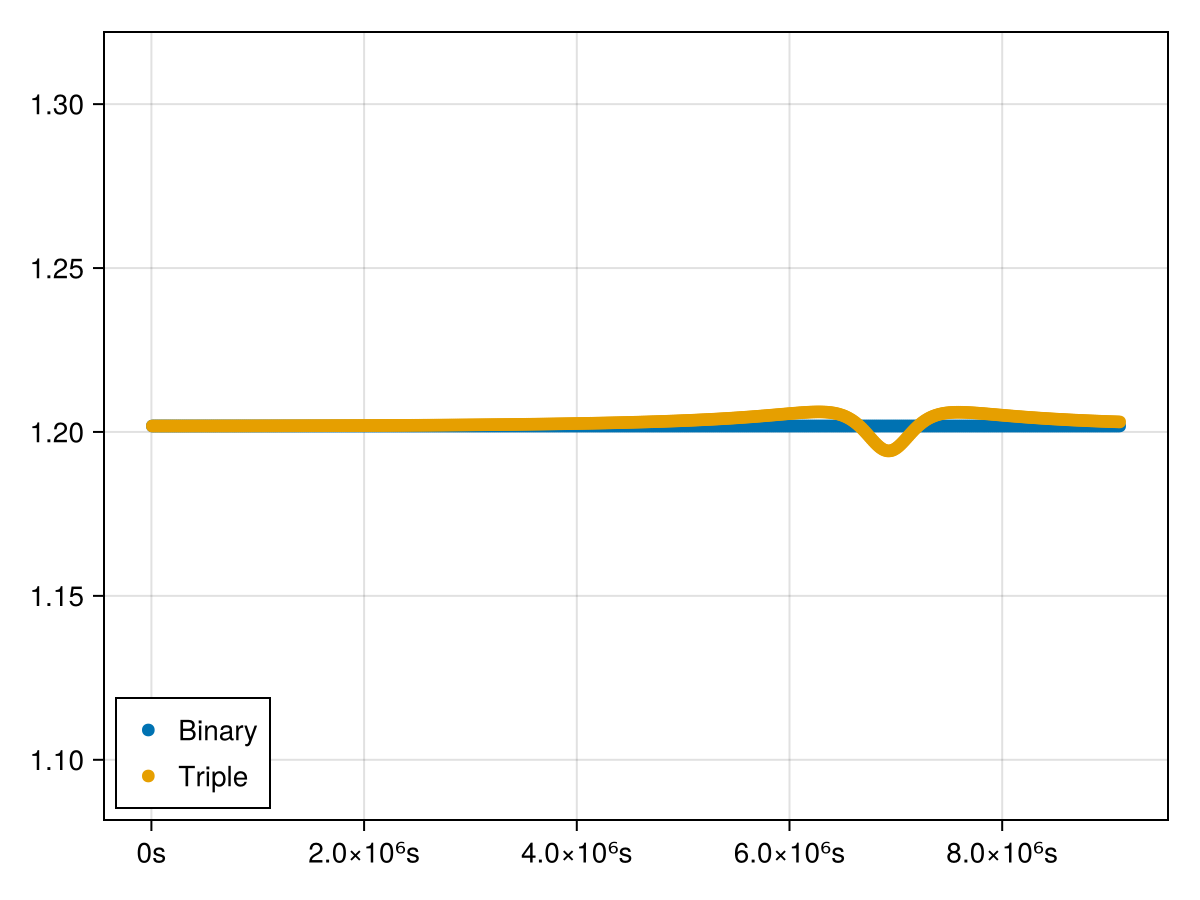

In [39]:
let 
    m = [53.3216769873, 53.3216769873, 42.3328244064]Msun
    a = [7.05396311596, 657.061190187]Rsun
    e = [0.829625, 0.698111]
    R = Syzygy.gravitational_radius.(m)
    triple = multibodysystem(m, a=a, e=e, stellar_types=[14, 14, 14], radii=R, i = [0.87371, 0.0])
    binary = multibodysystem(m[1:2], a=a[1], e=e[1], stellar_types=[14, 14], radii=R[1:2])

    pot = [PureGravitationalPotential(triple), PN2p5Potential(triple)]
    pot_bin = [PureGravitationalPotential(binary), PN2p5Potential(binary)]

    fig = Figure()
    ax = Axis(fig[1, 1])
    T = 500binary.binaries[1].P

    rps_bin, t_rps_bin = let
        sol = simulate(binary, t_sim=T, potential=pot_bin, alg=Syzygy.ODESolvers.FineRKN5, 
                            force_dtmin=true, callbacks=[], max_cpu_time=5, 
                            abstol=1e-13, reltol=1e-13) |> postprocess;
        d = ustrip.(Rsun, norm.(eachcol(sol.r[particle=1] .- sol.r[particle=2])))
        ids, _ = findmaxima(-d)
        # ids = eachindex(d)

        d[ids], sol.t[ids]
    end

    rps_trip, t_rps_trip = let
        sol = simulate(triple, t_sim=T, potential=pot, alg=Syzygy.ODESolvers.FineRKN5, 
                            force_dtmin=true, callbacks=[], max_cpu_time=5, 
                            abstol=1e-13, reltol=1e-13) |> postprocess;
        d = ustrip.(Rsun, norm.(eachcol(sol.r[particle=1] .- sol.r[particle=2])))
        ids, _ = findmaxima(-d)

        d[ids], sol.t[ids]
    end

    ylims!(ax, 0.9*ustrip(Rsun, a[1]*(1 - e[1])), 1.1*ustrip(Rsun, a[1]*(1 - e[1])))

    scatter!(ax, t_rps_bin, rps_bin, label="Binary")
    scatter!(ax, t_rps_trip, rps_trip, label="Triple")
    axislegend(ax, position=:lb)
    fig
end

Dict{Symbol, Any}(:DiffEq => :Terminated, :MaxCPUTime => true)
Dict{Symbol, Any}(:DiffEq => :Terminated, :MaxCPUTime => true)


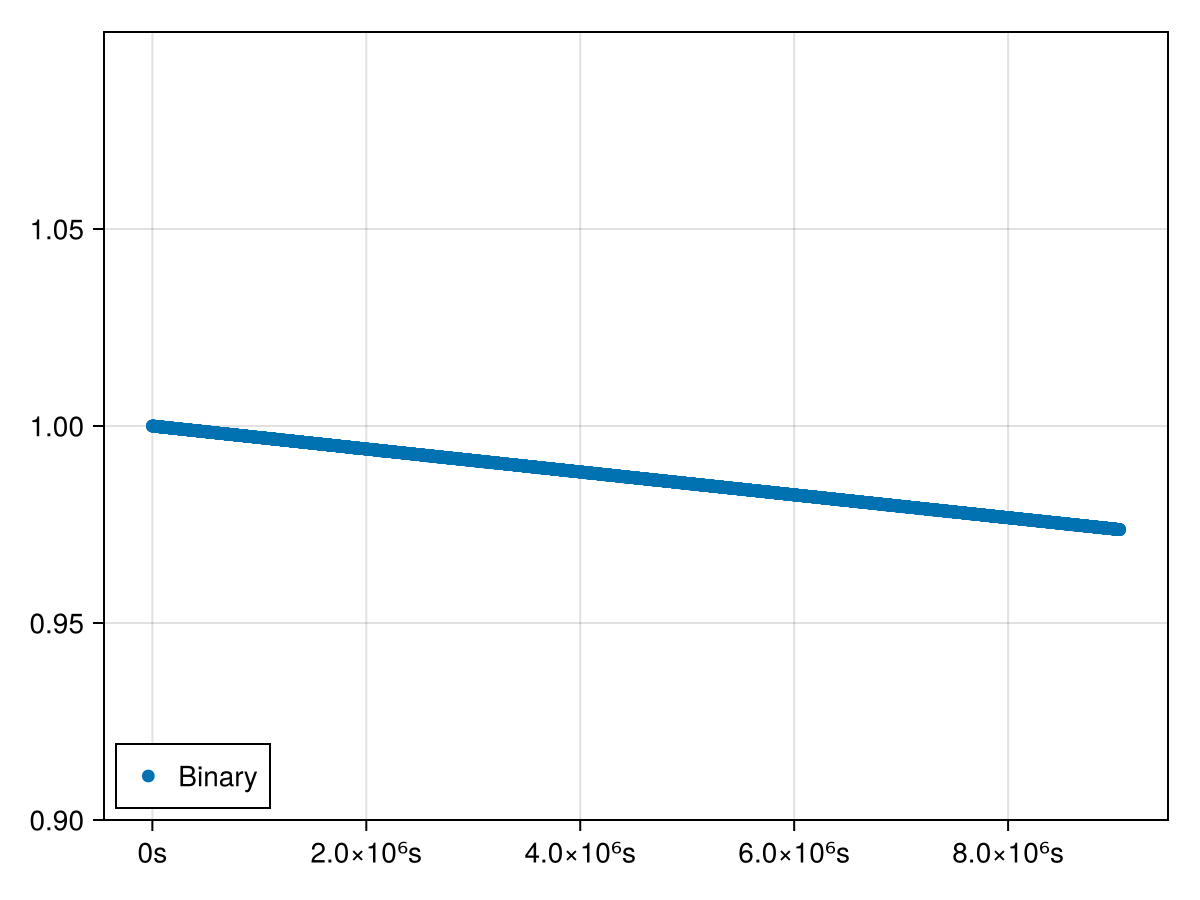

In [85]:
let 
    m = [53.3216769873, 53.3216769873, 42.3328244064]Msun
    a = [1.05396311596, 657.061190187]Rsun
    e = [0.829625, 0.698111]
    R = Syzygy.gravitational_radius.(m)
    triple = multibodysystem(m, a=a, e=e, stellar_types=[14, 14, 14], radii=R, i = [0.87371, 0.0])
    binary = multibodysystem(m[1:2], a=a[1], e=e[1], stellar_types=[14, 14], radii=R[1:2])

    pot = [PureGravitationalPotential(triple), PNPotential(triple)]
    pot_bin = [PureGravitationalPotential(binary), PNPotential(binary)]

    fig = Figure()
    ax = Axis(fig[1, 1])

    P = binary.binaries[1].P
    T = 10000P

    a_bin, e_bin, t_bin = let
        sol = simulate(binary, t_sim=T, potential=pot_bin, alg=Syzygy.ODESolvers.FineRKN5, 
                            force_dtmin=true, callbacks=[], max_cpu_time=10, 
                            abstol=1e-13, reltol=1e-13, saveat=P) |> postprocess;
        println(sol.ode_system[:retcodes])
        a, e = get_inner_orbital_elements(sol)
        a, e, sol.t
    end

    a_trip, e_trip, t_trip = let
        sol = simulate(triple, t_sim=T, potential=pot, alg=Syzygy.ODESolvers.FineRKN5, 
                            force_dtmin=true, callbacks=[], max_cpu_time=10, 
                            abstol=1e-13, reltol=1e-13, saveat=P) |> postprocess;
        println(sol.ode_system[:retcodes])
        a, e = get_inner_orbital_elements(sol)
        a, e, sol.t
    end

    ylims!(ax, 0.9, 1.1)

    scatter!(ax, t_bin, a_bin ./ a_bin[1], label="Binary", color=Makie.wong_colors()[1])
    # scatter!(ax, t_trip, a_trip ./ a_trip[1], label="Triple", color=Makie.wong_colors()[2])
    axislegend(ax, position=:lb)
    fig
end